# Pump failure example with Pareto prior

This notebook demonstrates the use of `MGFDerivative` with a Pareto prior for the Poisson likelihood, using the classic pump failure data from Gaver and O'Muircheartaigh (1987).

We will:
- Compute the model evidence (marginal likelihood)
- Compute the posterior density
- Compute the posterior predictive mass for a new observation
- Compute the posterior MGF and moments
- Demonstrate sequential updating by splitting the data into two chunks

All examples use the **single‑rate model** with a diffuse Pareto prior $ \Lambda \sim \text{Pareto}(\alpha=10^{-5}, \xi=10^{-5}) $. This matches the setup in the paper.

## Setup

In [1]:
import pandas as pd
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from jumufraktiv.MGFDerivative_class import MGFDerivative
from jumufraktiv.like_stats.Poisson import readyPoisson
from scipy.special import expn
import mpmath as mp
import numpy as np
import math

plt.style.use('seaborn-v0_8-whitegrid')

## Pump failure data

In [2]:
data = pd.DataFrame({
    't': [94.32, 15.72, 62.88, 125.76, 5.24, 31.44, 1.048, 1.048, 2.096, 10.48],
    'y': [5, 1, 5, 14, 3, 19, 1, 1, 4, 22]
})
print("Data:")
display(data)

Data:


,t,y
0,94.320,5
1,15.720,1
2,62.880,5
3,125.760,14
4,5.240,3
5,31.440,19
6,1.048,1
7,1.048,1
8,2.096,4
9,10.480,22


## Prior specification

We use a Pareto prior with shape `α = 1e-5` and scale `ξ = 1e-5` (very diffuse). Note that the Poisson likelihood gives an integer derivative order (`a = sum(y_i)`), so we will use `method='symbolic'` for exact computation.

## 1. Model evidence

The evidence is computed via the derivative of the prior MGF at `t = -b`. We compute it symbolically and compare with the analytic formula from the paper.

In [3]:
# Compute evidence using the package
from jumufraktiv.mitMGFprior_class import mitMGFprior
import jumufraktiv.MGFdictionary  # registers priors

alpha_prior = 1e-5
xi_prior = 1e-5

# ---- Create Pareto prior object ----
pareto_prior = mitMGFprior.from_registry(
    "pareto",
    params={"alpha": alpha_prior, "xi": xi_prior}
)

deriv = MGFDerivative(
    prior=pareto_prior,   # prior object
    data=data['y'],
    likelihood='poisson',
    method='symbolic',
    scale=data['t']       # likelihood parameter
)

log_ev_pkg, sign_pkg = deriv.evidence()
print(f"Package log evidence: {log_ev_pkg:.6f}, sign = {sign_pkg}")

Package log evidence: -91.738538, sign = 1


**1.2 Analytical verification using the paper's formula**

The evidence for the single‑rate Pareto‑Poisson model is given by Equation (14) in the paper:

$$
p(\mathbf{y}) = \left(\prod_{i=1}^n \frac{t_i^{y_i}}{y_i!}\right) \, \alpha \, \xi^{\sum y_i} \, E_{\alpha+1-\sum y_i}\left(\xi \sum t_i\right),
$$

where $E_n(z)$ is the exponential integral function. We can verify the package result by directly substituting the hyperparameters into the symbolic derivative expression obtained from the package.

In [4]:
# Set high precision for accurate evaluation
mp.mp.dps = 50  # note: use mp.mp.dps, not mp.dps

# Compute statistics
a = sum(data['y'])
b = sum(data['t'])
c_val = np.prod(data['t']**data['y'] / [math.factorial(int(yi)) for yi in data['y']])

# Hyperparameters
alpha_prior = 1e-5
xi_prior = 1e-5

# Order and argument of the exponential integral
n_expint = alpha_prior + 1 - a
z_expint = xi_prior * b

# Evaluate E_n(z) using mpmath (supports negative n)
E_val = mp.expint(n_expint, z_expint)

# Compute log evidence
log_ev_analytic = np.log(c_val) + np.log(alpha_prior) + a * np.log(xi_prior) + np.log(float(E_val))
print(f"Analytical log evidence (mpmath): {log_ev_analytic:.6f}")

# Compare with package result (from previous chunk)
print(f"Package log evidence: {log_ev_pkg:.6f}")
print(f"Difference: {log_ev_analytic - log_ev_pkg:.2e}")

Analytical log evidence (mpmath): -91.738538
Package log evidence: -91.738538
Difference: -2.84e-14


## 2. Posterior density

The posterior density is given by (16). We compute it over a range of λ values and plot.

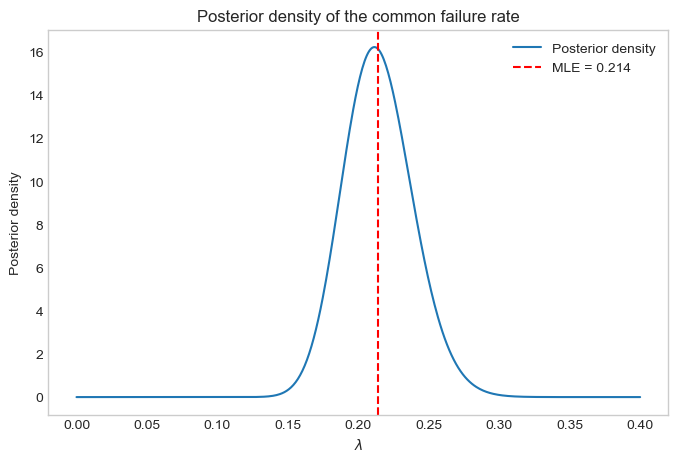

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Compute MLE ----
a = sum(data['y'])
b = sum(data['t'])
mle = a / b

# ---- Posterior density ----
lambda_vals = np.linspace(1e-6, 0.4, 500)
log_post = deriv.post_density(lambda_vals, log=True)
post = np.exp(log_post)

# ---- Plot ----
plt.figure(figsize=(8,5))
plt.plot(lambda_vals, post, label='Posterior density')
plt.axvline(x=mle, color='r', linestyle='--', label=f'MLE = {mle:.3f}')
plt.xlabel(r'$\lambda$')
plt.ylabel('Posterior density')
plt.title('Posterior density of the common failure rate')
plt.legend()
plt.grid()
plt.show()

In [6]:
import sympy as sp
from jumufraktiv.mitMGFprior_class import mitMGFprior
from jumufraktiv.symbols import t, theta, param
from jumufraktiv.MGFDerivative_class import MGFDerivative

# ---- Define symbolic hyperparameters for Pareto ----
alpha_sym = param("alpha")
xi_sym = param("xi")

# ---- Create a symbolic Pareto prior using the registry ----
symbolic_prior = mitMGFprior.from_registry(
    "pareto",
    params={'alpha': alpha_sym, 'xi': xi_sym}   # <-- symbols
)

# ---- Pass to MGFDerivative ----
# Use the same data (e.g., pump failure data)
deriv_sym = MGFDerivative(
    prior=symbolic_prior,
    data=data['y'],
    likelihood='poisson',
    method='auto',
    scale=data['t']
)

# ---- Check result ----
print(f"deriv_sym.is_symbolic = {deriv_sym.is_symbolic}")   # Should be True

# ---- Compute symbolic posterior density ----
post_expr = deriv_sym.post_density(theta, log=False)
print("Symbolic posterior density (Pareto prior):")
sp.pprint(post_expr, use_unicode=False)

deriv_sym.is_symbolic = True
Symbolic posterior density (Pareto prior):
     75.0      -alpha - 1   alpha  -350.032*theta
theta    *theta          *xi     *e              
-------------------------------------------------
         75                                      
       xi  *expint(alpha - 74, 350.032*xi)       


## 3. Posterior predictive mass

We compute the predictive mass for a new observation at pump 4's exposure (`t_new = 125.76`) and compare with the observed `y=14`.

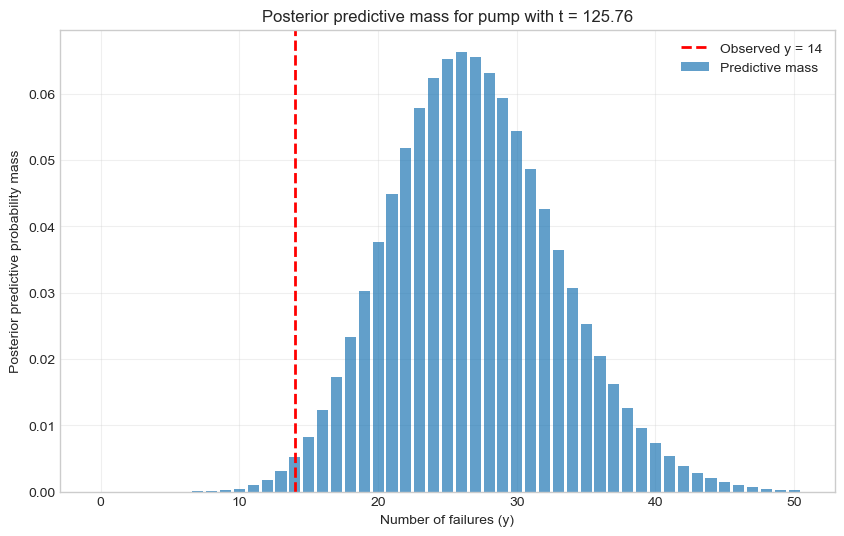

Predictive mass at y=14: 5.246825e-03


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Parameters for pump 4 ----
t_new = 125.76
y_obs = 14

# ---- Compute predictive mass for y = 0..50 ----
y_vals = np.arange(0, 51)
pred_masses = []

for y in y_vals:
    log_pred = deriv.post_predictive(
        pd.DataFrame({'y': [y]}),
        scale=t_new,
        log=True
    )
    pred_masses.append(np.exp(log_pred))

# ---- Plot ----
plt.figure(figsize=(10, 6))
plt.bar(y_vals, pred_masses, width=0.8, alpha=0.7, label='Predictive mass')
plt.axvline(x=y_obs, color='r', linestyle='--', linewidth=2, label=f'Observed y = {y_obs}')
plt.xlabel('Number of failures (y)')
plt.ylabel('Posterior predictive probability mass')
plt.title(f'Posterior predictive mass for pump with t = {t_new}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ---- Also print the predictive mass at the observed value ----
log_pred_obs = deriv.post_predictive(
    pd.DataFrame({'y': [y_obs]}),
    scale=t_new,
    log=True
)
print(f"Predictive mass at y={y_obs}: {np.exp(log_pred_obs):.6e}")

In [8]:
import pandas as pd
import sympy as sp
from jumufraktiv.symbols import t, theta, param
from jumufraktiv.MGFDerivative_class import MGFDerivative

# ---- Assume deriv_sym is a symbolic MGFDerivative object (from previous step) ----
# It should have is_symbolic = True and contain symbolic hyperparameters.

# ---- New observation ----
y_new = 14
t_new = 125.76

# ---- Compute symbolic predictive mass ----
pred_mass_expr = deriv_sym.post_predictive(
    pd.DataFrame({'y': [y_new]}),
    scale=t_new,
    log=False          # return ordinary density (not log)
)

print("Symbolic posterior predictive mass expression:")
sp.pprint(pred_mass_expr, use_unicode=False)


Symbolic posterior predictive mass expression:
                       14                               
2.83914157710757e+18*xi  *expint(alpha - 88, 475.792*xi)
--------------------------------------------------------
             expint(alpha - 74, 350.032*xi)             


## 4. Posterior MGF

The posterior MGF as a function of `r` (for `r < 0`):

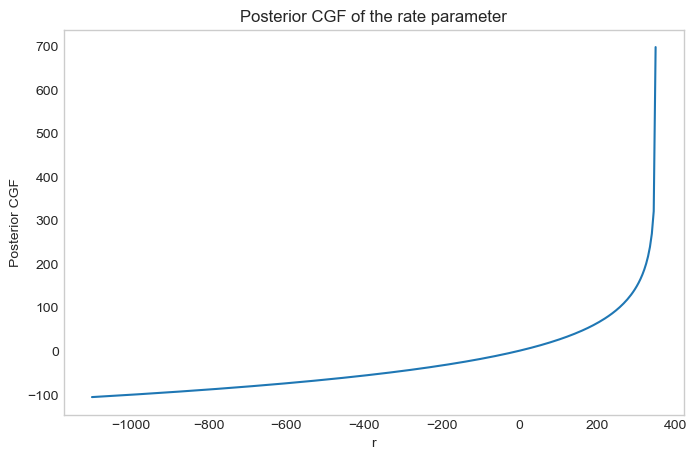

In [9]:
r_vals = np.linspace(-1e3-100, 350, 300)
cgf_vals = [deriv.post_mgf(r, log=True) for r in r_vals]

plt.figure(figsize=(8,5))
plt.plot(r_vals, cgf_vals)
plt.xlabel('r')
plt.ylabel('Posterior CGF')
plt.title('Posterior CGF of the rate parameter')
plt.grid()
plt.show()

In [10]:
import sympy as sp
from jumufraktiv.symbols import param

# ---- Define symbolic variable for r (the MGF argument) ----
r_sym = sp.Symbol('r', real=True)

# ---- Compute symbolic posterior MGF (ordinary scale) ----
post_mgf_expr = deriv_sym.post_mgf(r_sym, log=False)

print("Symbolic posterior MGF (ordinary scale):")
sp.pprint(post_mgf_expr, use_unicode=False)

# ---- Compute symbolic posterior log‑MGF (CGF) ----
post_cgf_expr = deriv_sym.post_mgf(r_sym, log=True)

print("\nSymbolic posterior CGF (log MGF):")
sp.pprint(post_cgf_expr, use_unicode=False)

Symbolic posterior MGF (ordinary scale):
expint(alpha - 74, -xi*(r - 350.032))
-------------------------------------
   expint(alpha - 74, 350.032*xi)    

Symbolic posterior CGF (log MGF):
     /        75                               \      /        75              >
- log\alpha*xi  *expint(alpha - 74, 350.032*xi)/ + log\alpha*xi  *expint(alpha >

>                          \
>  - 74, -xi*(r - 350.032))/


## 5. Posterior raw moments

We compute the first few moments (mean, variance, etc.) using the `post_moment` method. As 'symbolic' method does not work well on fractional orders of derivatives, we focus on integer-ordered moments only.


Number of selected orders: 10
Selected orders (q): [ -75   56  186  317  447  578  708  839  969 1100]
Computing moment for q=-75...
Computed log|E[Θ^-75]| = 193.404546
Computing moment for q=56...
Computed log|E[Θ^56]| = -69.489471
Computing moment for q=186...
Computed log|E[Θ^186]| = -147.688674
Computing moment for q=317...
Computed log|E[Θ^317]| = -157.898561
Computing moment for q=447...
Computed log|E[Θ^447]| = -123.817175
Computing moment for q=578...
Computed log|E[Θ^578]| = -56.362999
Computing moment for q=708...
Computed log|E[Θ^708]| = 36.766040
Computing moment for q=839...
Computed log|E[Θ^839]| = 152.551696
Computing moment for q=969...
Computed log|E[Θ^969]| = 286.095472
Computing moment for q=1100...
Computed log|E[Θ^1100]| = 437.087046
Computed log|E[Θ^q]| values: [np.float64(193.40454600023287), np.float64(-69.48947077687356), np.float64(-147.68867435959586), np.float64(-157.89856079536966), np.float64(-123.81717505620409), np.float64(-56.362999384104995), np.float6

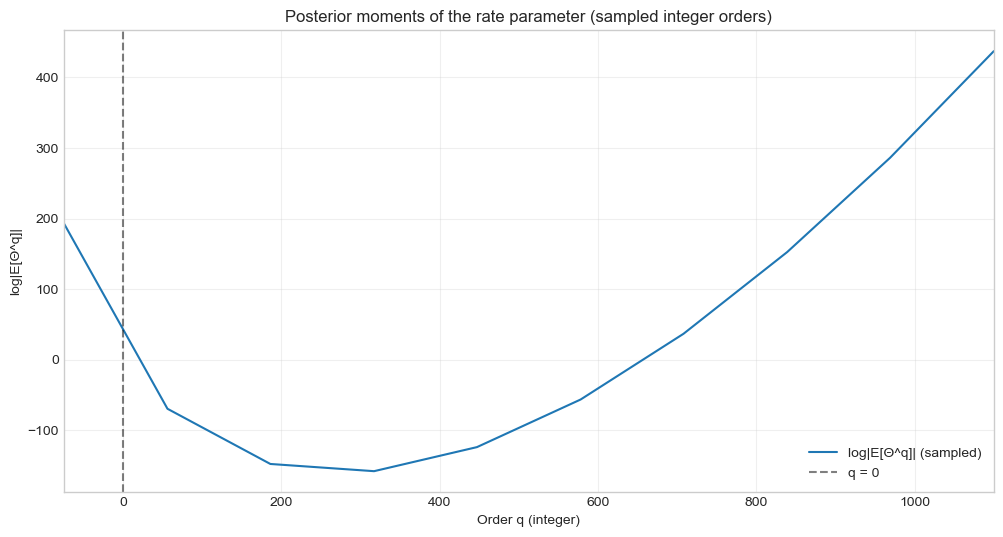

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Compute sufficient statistics ----
a = sum(data['y'])        # Σ y_i (e.g., 75)

# ---- Define order range ----
q_min = -int(a)           # e.g., -75
q_max = 1100

# ---- Select 100 evenly spaced integers between q_min and q_max ----
q_vals = np.unique(np.round(np.linspace(q_min, q_max, 10)).astype(int))
# Ensure q_min and q_max are included (just in case)
if q_min not in q_vals:
    q_vals = np.append(q_min, q_vals)
if q_max not in q_vals:
    q_vals = np.append(q_vals, q_max)
q_vals = np.sort(q_vals)

print(f"Number of selected orders: {len(q_vals)}")
print(f"Selected orders (q): {q_vals}")

# ---- Compute log|E[Θ^q]| for each selected order ----
log_abs_moments = []

for q in q_vals:
    try:
        print(f"Computing moment for q={q}...")
        log_abs = deriv.post_raw_moment(int(q), log=True, numerator_method='symbolic')
        log_abs_moments.append(log_abs)
        print(f"Computed log|E[Θ^{q}]| = {log_abs:.6f}")
    except Exception:
        log_abs_moments.append(np.nan)
        print(f"Warning: Could not compute moment for q={q}. Appending NaN.")

# ---- Plot ----
print(f"Computed log|E[Θ^q]| values: {log_abs_moments}")
log_abs_moments = np.array(log_abs_moments)
print(f"start printing log_abs_moments: {log_abs_moments}")
plt.figure(figsize=(12, 6))
plt.plot(q_vals, log_abs_moments, linestyle='-', linewidth=1.5, label='log|E[Θ^q]| (sampled)')
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5, label='q = 0')
plt.xlabel('Order q (integer)')
plt.ylabel('log|E[Θ^q]|')
plt.title('Posterior moments of the rate parameter (sampled integer orders)')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(q_min, q_max)
plt.show()

As SymPy does not support differentiations up to symbolic orders, the symbolic method to calculate posterior moments is not supported.

In [12]:
import sympy as sp
from jumufraktiv.symbols import param

# ---- Define symbolic variable for the moment order ----
q_sym = sp.Symbol('q', real=True)

# ---- Compute symbolic posterior moment (ordinary scale) ----
post_moment_expr = deriv_sym.post_raw_moment(q_sym, log=False)

print("Symbolic posterior moment E[θ^q] (ordinary scale):")
sp.pprint(post_moment_expr, use_unicode=False)

# ---- Compute symbolic log‑moment (log of absolute value) ----
post_log_moment_expr = deriv_sym.post_raw_moment(q_sym, log=True)

print("\nSymbolic posterior log‑moment log|E[θ^q]|:")
sp.pprint(post_log_moment_expr, use_unicode=False)

/Users/jl1023/Documents/GitHub/jumufraktiv/jumufraktiv/derivativeDispatch.py:423: UserWarning: Derivative order contains symbolic variables. Using integerDeriv_symbolic() as a formal symbolic derivative. The resulting expression is often the analytic continuation to non-integer orders, but this is not guaranteed.
  warnings.warn(


RuntimeError: Symbolic computation failed: SymPy currently does not support symbolic differentiation for orders other than integers, including symbolic orders.. Falling back to numeric.

## 6. Posterior central moments

In [34]:
print("=" * 60)
print("Testing central moments (orders 1–4)")
print("=" * 60)

# ---- For each order, compute both log and ordinary ----
for order in [1, 2, 3, 4]:
    try:
        # Log‑scale: returns (log_abs, sign)
        log_abs, sign = deriv.post_central_moment(order, log=True, numerator_method='symbolic')
        print(f"Central moment {order} (log-scale):")
        if isinstance(log_abs, sp.Expr):
            print(f"  log|.| = symbolic expression:")
            sp.pprint(log_abs, use_unicode=False)
            print(f"  sign = {sign}")
        else:
            print(f"  log|.| = {log_abs:.6f}, sign = {sign}")
    except Exception as e:
        print(f"  Log‑scale computation failed for order {order}: {e}")

    try:
        # Ordinary scale
        val = deriv.post_central_moment(order, log=False, numerator_method='symbolic')
        if isinstance(val, sp.Expr):
            print(f"Central moment {order} (ordinary, symbolic):")
            sp.pprint(val, use_unicode=False)
        else:
            print(f"Central moment {order} (ordinary, numeric): {val:.6e}")
    except Exception as e:
        print(f"  Ordinary‑scale computation failed for order {order}: {e}")

    print("-" * 40)

Testing central moments (orders 1–4)
Central moment 1 (log-scale):
  log|.| = -inf, sign = 1
Central moment 1 (ordinary, numeric): 0.000000e+00
----------------------------------------
Central moment 2 (log-scale):
  log|.| = -7.398561, sign = 1
Central moment 2 (ordinary, numeric): 6.121329e-04
----------------------------------------
Central moment 3 (log-scale):
  log|.| = -12.563439, sign = 1
Central moment 3 (ordinary, numeric): 3.497582e-06
----------------------------------------
Central moment 4 (log-scale):
  log|.| = -13.672193, sign = 1
Central moment 4 (ordinary, numeric): 1.154097e-06
----------------------------------------


## 7. Sequential updating

We split the data into two chunks: first 5 pumps, then the remaining 5. We update sequentially and compare the final evidence with the full-dataset evidence.

### symbolic-symbolic

In [13]:
import time
from jumufraktiv.mitMGFprior_class import mitMGFprior
import jumufraktiv.MGFdictionary
from jumufraktiv.MGFDerivative_class import MGFDerivative

# ---- Create non‑informative Gamma prior ----
alpha_prior = 1e-5
beta_prior = 1e-5
gamma_prior = mitMGFprior.from_registry(
    "gamma",
    params={"alpha": alpha_prior, "beta": beta_prior}
)

# ---- Split data ----
data1 = data.iloc[:5]
data2 = data.iloc[5:]

# ---- First chunk ----
deriv1 = MGFDerivative(
    prior=pareto_prior,
    data=data1['y'],
    likelihood='poisson',
    method='auto',
    scale=data1['t']
)

# ---- Investigate deriv1 ----
print(f"deriv1._is_symbolic = {deriv1._is_symbolic}")
print(f"deriv1._deriv_is_symbolic = {deriv1._deriv_is_symbolic}")

# ---- Now call update() ----
deriv2 = deriv1.update(
    new_data=data2['y'],
    method='auto',
    scale=data2['t']
)

# ---- Investigate deriv2 ----
print(f"\nderiv2._is_symbolic = {deriv2._is_symbolic}")
print(f"deriv2._deriv_is_symbolic = {deriv2._deriv_is_symbolic}")
print(f"deriv2.prior.mgf_sym is None? {deriv2.prior.mgf_sym is None}")

# ---- Also check the prior's backend ----
print(f"deriv2.prior.mgf_backend is None? {deriv2.prior.mgf_backend is None}")

deriv1._is_symbolic = False
deriv1._deriv_is_symbolic = True

deriv2._is_symbolic = False
deriv2._deriv_is_symbolic = True
deriv2.prior.mgf_sym is None? False
deriv2.prior.mgf_backend is None? True


### model evidence

In [14]:
log_ev_pkg1, sign_pkg1 = deriv1.evidence()
print(f"Package log evidence by sequential update: {log_ev_pkg1:.6f}, sign = {sign_pkg1}")

log_ev_pkg2, sign_pkg2 = deriv2.evidence()
print(f"Package log evidence by sequential update: {log_ev_pkg2:.6f}, sign = {sign_pkg2}")

print(f"Total evidence: {log_ev_pkg1 + log_ev_pkg2:.2e}")
print(f"Difference with first evidence: {log_ev_pkg1 + log_ev_pkg2 - log_ev_pkg:.2e}")

Package log evidence by sequential update: -24.738088, sign = 1
Package log evidence by sequential update: -67.000450, sign = 1
Total evidence: -9.17e+01
Difference with first evidence: -1.42e-14


### posterior density

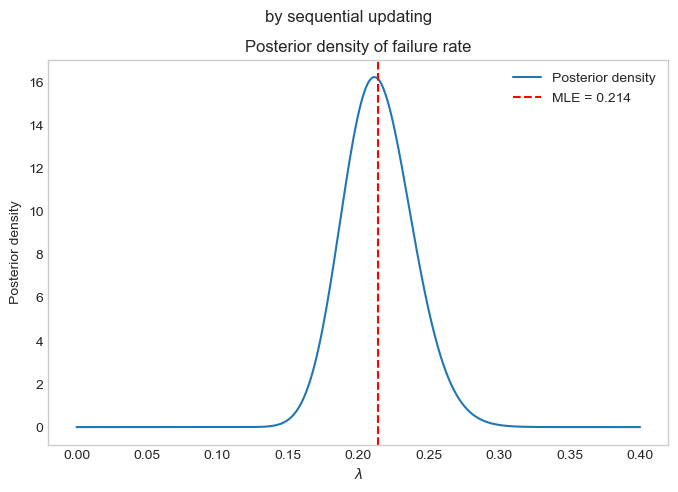

In [15]:
log_post2 = deriv2.post_density(lambda_vals, log=True)
post2 = np.exp(log_post2)

# ---- Plot ----
plt.figure(figsize=(8,5))
plt.plot(lambda_vals, post2, label='Posterior density')
plt.axvline(x=mle, color='r', linestyle='--', label=f'MLE = {mle:.3f}')
plt.xlabel(r'$\lambda$')
plt.ylabel('Posterior density')
plt.title('Posterior density of failure rate')
plt.suptitle('by sequential updating')
plt.legend()
plt.grid()
plt.show()

### posterior predictive

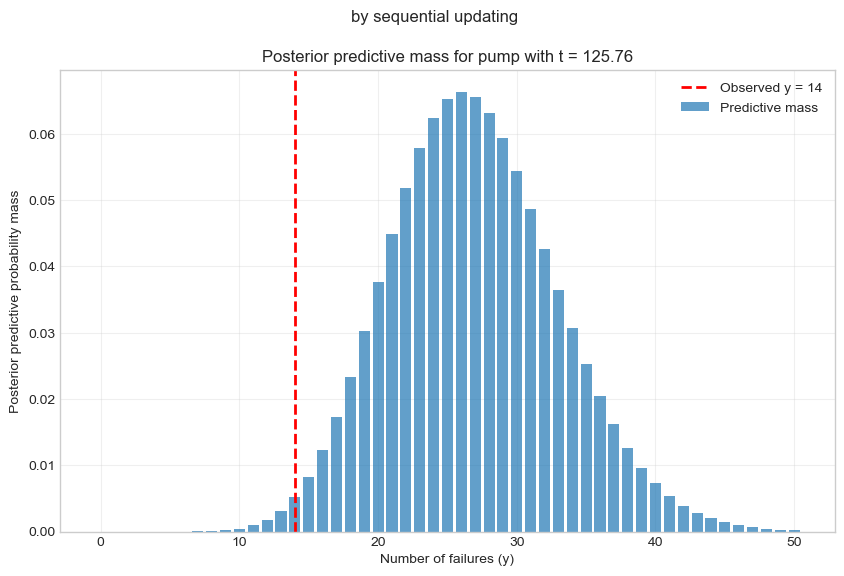

Predictive mass at y=14: 5.246825e-03


In [36]:
# ---- Compute predictive mass for y = 0..50 ----
y_vals = np.arange(0, 51)
pred_masses2 = []

for y in y_vals:
    log_pred2 = deriv2.post_predictive(
        pd.DataFrame({'y': [y]}),
        scale=t_new,
        log=True
    )
    pred_masses2.append(np.exp(log_pred2))

# ---- Plot ----
plt.figure(figsize=(10, 6))
plt.bar(y_vals, pred_masses2, width=0.8, alpha=0.7, label='Predictive mass')
plt.axvline(x=y_obs, color='r', linestyle='--', linewidth=2, label=f'Observed y = {y_obs}')
plt.xlabel('Number of failures (y)')
plt.ylabel('Posterior predictive probability mass')
plt.title(f'Posterior predictive mass for pump with t = {t_new}')
plt.suptitle('by sequential updating')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ---- Also print the predictive mass at the observed value ----
log_pred_obs = deriv.post_predictive(
    pd.DataFrame({'y': [y_obs]}),
    scale=t_new,
    log=True
)
print(f"Predictive mass at y={y_obs}: {np.exp(log_pred_obs):.6e}")

### posterior MGF

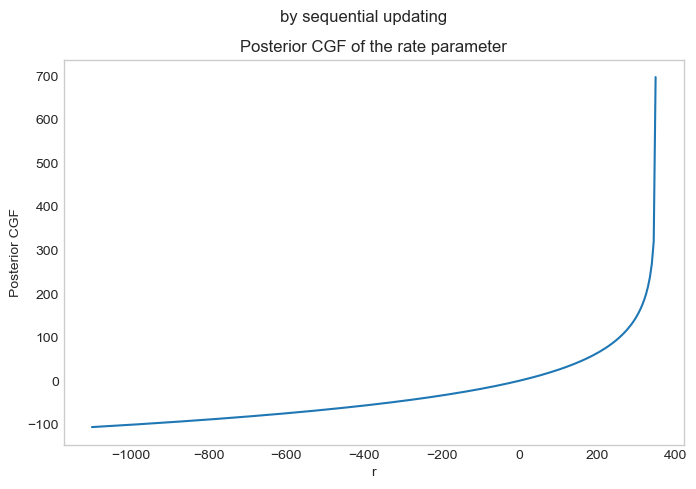

In [16]:
cgf_vals2 = [deriv2.post_mgf(r, log=True) for r in r_vals]

plt.figure(figsize=(8,5))
plt.plot(r_vals, cgf_vals2)
plt.xlabel('r')
plt.ylabel('Posterior CGF')
plt.title('Posterior CGF of the rate parameter')
plt.suptitle('by sequential updating')
plt.grid()
plt.show()

### posterior moments
Sequential updating sometimes narrows down the range of which the posterior moments are defined. In this example, the negative posterior moments are defined up to -a, the differentiation order. However, the 'a' in the sequential update is twofold: the order determined by the first or second set of data; only the latter determines the boundary of the order of negative posterior moments.

In [29]:
print("lower bound of negative posterior moments in one-step inference", -deriv.a)
print("lower bound of negative posterior moments in sequential updates", -deriv2.a)

lower bound of negative posterior moments in one-step inference -75.0
lower bound of negative posterior moments in sequential updates -47.0


If we try, we get a derivative-order error:

In [33]:
print(deriv.post_raw_moment(int(-75), log=True, numerator_method='symbolic'))
print(deriv2.post_raw_moment(int(-75), log=True, numerator_method='symbolic'))

193.40454600023287


ValueError: Order of derivative must be non‑negative.

Number of selected orders: 10
Selected orders (q): [ -47   80  208  335  463  590  718  845  973 1100]
Computing moment for q=-47...
Computed log|E[Θ^-47]| = 92.311790
Computing moment for q=80...
Computed log|E[Θ^80]| = -91.086231
Computing moment for q=208...
Computed log|E[Θ^208]| = -153.284058
Computing moment for q=335...
Computed log|E[Θ^335]| = -155.475666
Computing moment for q=463...
Computed log|E[Θ^463]| = -117.195244
Computing moment for q=590...
Computed log|E[Θ^590]| = -48.779885
Computing moment for q=718...
Computed log|E[Θ^718]| = 44.874361
Computing moment for q=845...
Computed log|E[Θ^845]| = 158.326910
Computing moment for q=973...
Computed log|E[Θ^973]| = 290.472373
Computing moment for q=1100...
Computed log|E[Θ^1100]| = 437.087046
Computed log|E[Θ^q]| values: [np.float64(92.31178970362697), np.float64(-91.08623096923245), np.float64(-153.28405824965395), np.float64(-155.47566637912922), np.float64(-117.19524436197236), np.float64(-48.779885152752115), np.float64(

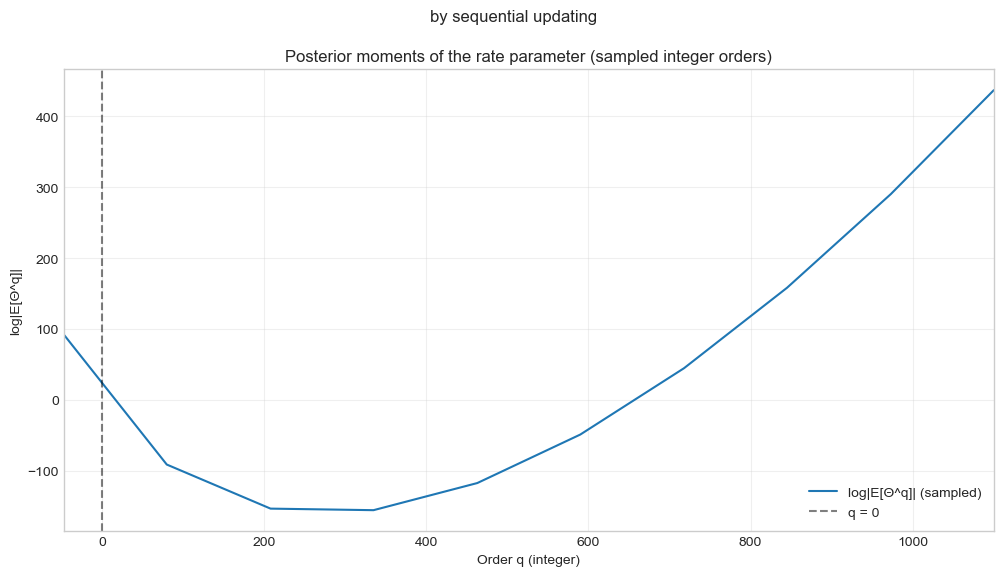

In [32]:
# ---- Define order range ----
q_min2 = -deriv2.a           # e.g., -75
q_max2 = 1100

# ---- Select 100 evenly spaced integers between q_min and q_max ----
q_vals2 = np.unique(np.round(np.linspace(q_min2, q_max2, 10)).astype(int))
# Ensure q_min and q_max are included (just in case)
if q_min2 not in q_vals2:
    q_vals2 = np.append(q_min2, q_vals2)
if q_max2 not in q_vals2:
    q_vals2 = np.append(q_vals2, q_max2)
q_vals2 = np.sort(q_vals2)

print(f"Number of selected orders: {len(q_vals2)}")
print(f"Selected orders (q): {q_vals2}")

# ---- Compute log|E[Θ^q]| for each selected order ----
log_abs_moments2 = []

for q in q_vals2:
    try:
        print(f"Computing moment for q={q}...")
        log_abs2 = deriv2.post_raw_moment(int(q), log=True, numerator_method='symbolic')
        log_abs_moments2.append(log_abs2)
        print(f"Computed log|E[Θ^{q}]| = {log_abs2:.6f}")
    except Exception:
        log_abs_moments2.append(np.nan)
        print(f"Warning: Could not compute moment for q={q}. Appending NaN.")

# ---- Plot ----
print(f"Computed log|E[Θ^q]| values: {log_abs_moments2}")
log_abs_moments2 = np.array(log_abs_moments2)
print(f"start printing log_abs_moments: {log_abs_moments2}")
plt.figure(figsize=(12, 6))
plt.plot(q_vals2, log_abs_moments2, linestyle='-', linewidth=1.5, label='log|E[Θ^q]| (sampled)')
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5, label='q = 0')
plt.xlabel('Order q (integer)')
plt.ylabel('log|E[Θ^q]|')
plt.title('Posterior moments of the rate parameter (sampled integer orders)')
plt.suptitle('by sequential updating')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(q_min2, q_max2)
plt.show()